In [ ]:
import sys
import os
# Add parent directory to path for module imports
sys.path.insert(0, os.path.abspath('../..'))

from codes.lsd_train import LSD
from codes.config import LSDConfig
import scanpy as sc
import pandas as pd
import scvelo as scv
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
import seaborn as sns
import torch
import numpy as np
import scipy.sparse as sp
import torch.nn as nn
import pyro
import random
device = torch.device("cuda")
SEED = 42
pyro.set_rng_seed(SEED)


/projects/apour/NDE311/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


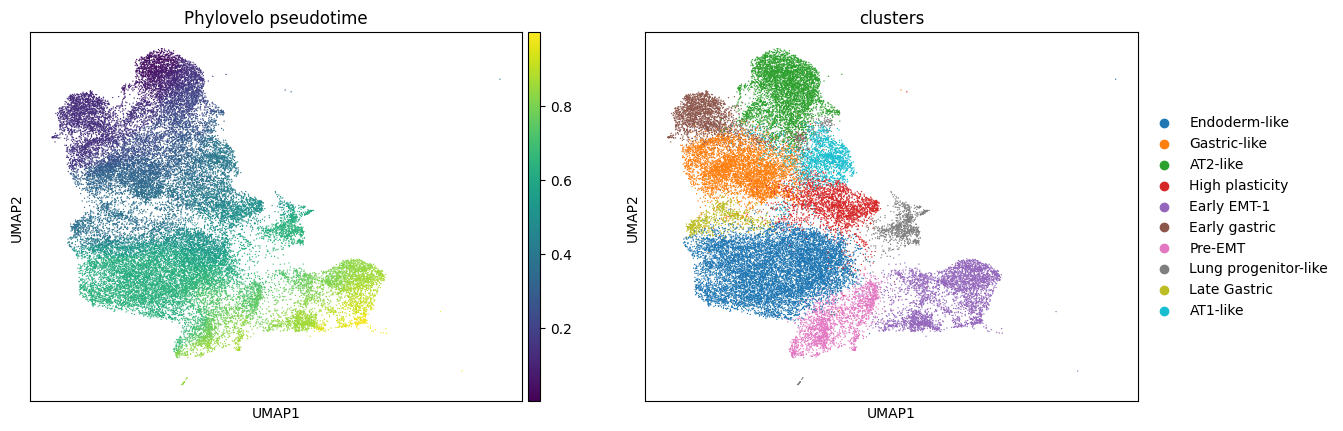

In [2]:
# -----------------------------------------------------------------------------
# 1. Load & inspect data
# -----------------------------------------------------------------------------
adata = sc.read_h5ad("../../data/KP_tracer/train_adata.h5ad")
# Quick UMAP to inspect pseudotime & clusters
sc.pl.umap(
    adata,
    color=["transferred_phylo_pseudotime", "clusters"],
    title="Phylovelo pseudotime"
)

[LSD] Prior transition matrix set from pseudotime and connectivities.


Training Epochs: 100%|██████████| 100/100 [23:24<00:00, 14.04s/it, -ELBO=0.4220, Potential Metric=0.1933, Entropy Metric=0.0543]


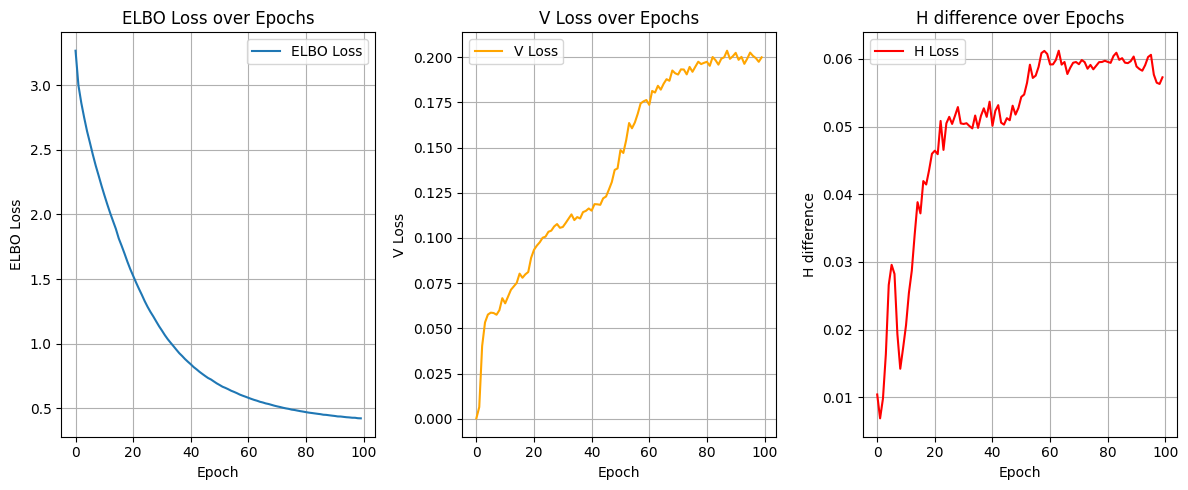

/projects/apour/NDE311/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


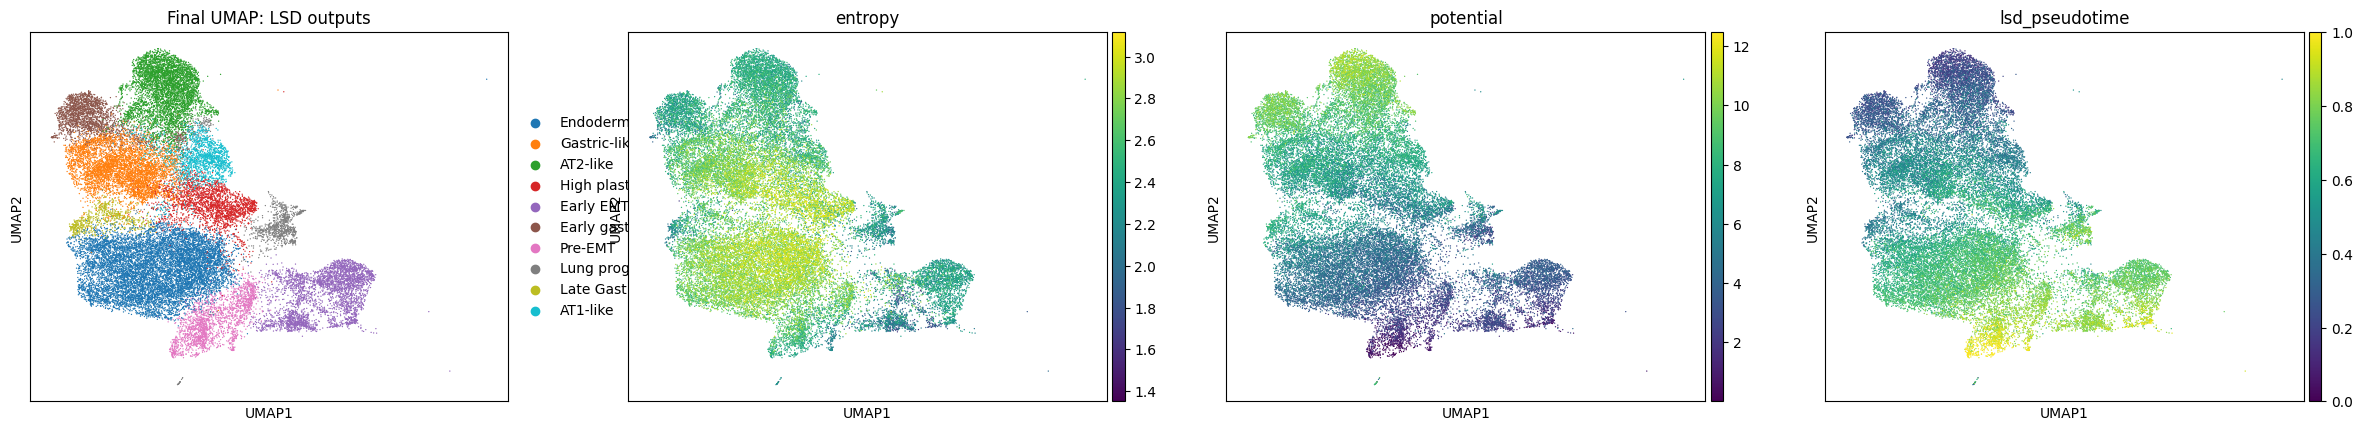

/projects/apour/NDE311/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


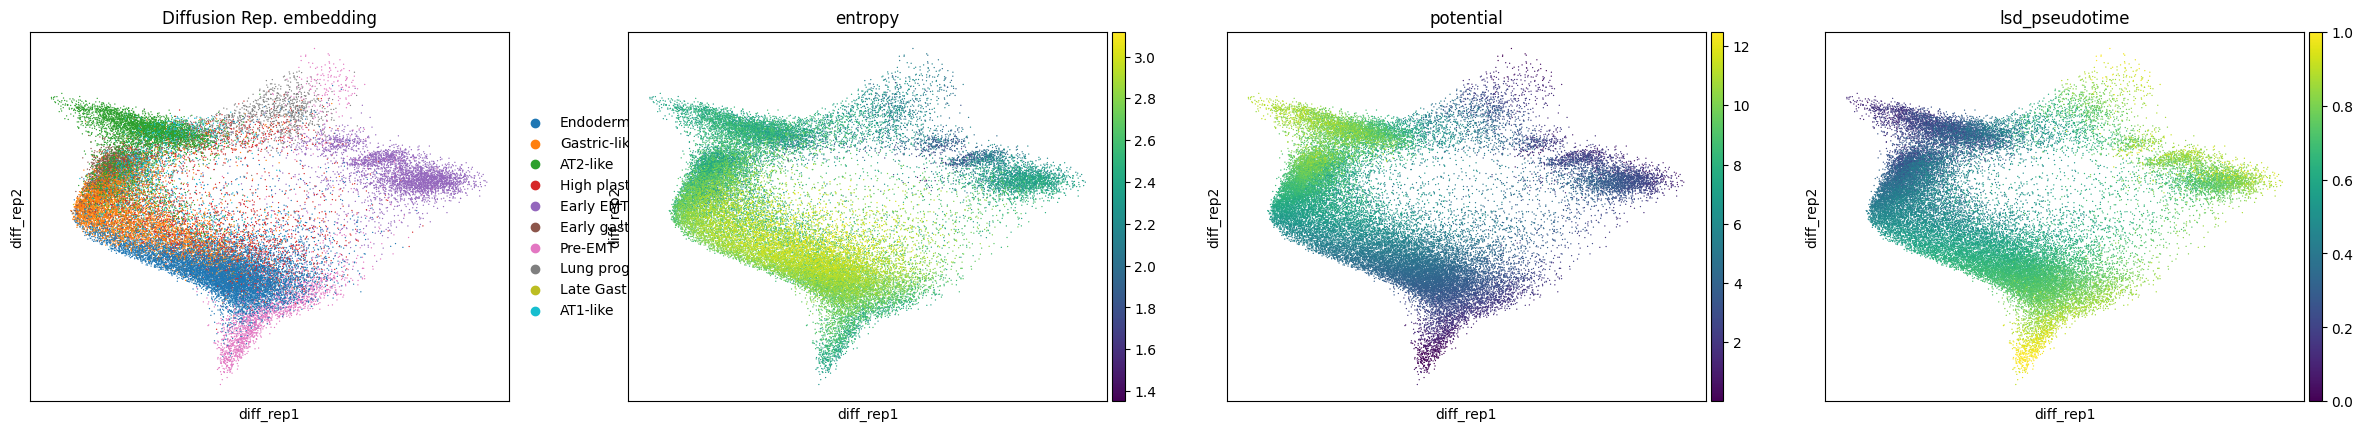

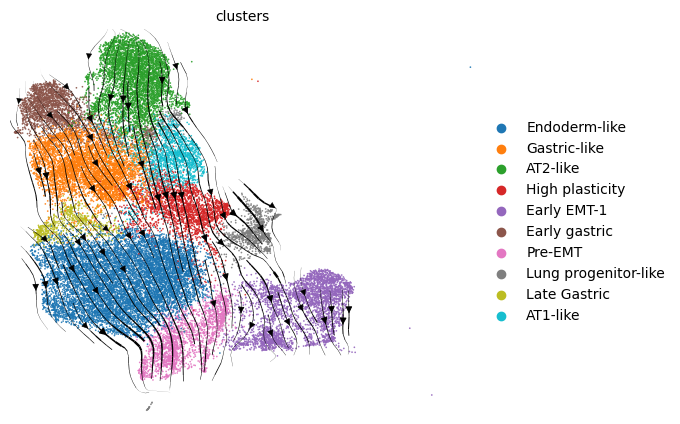

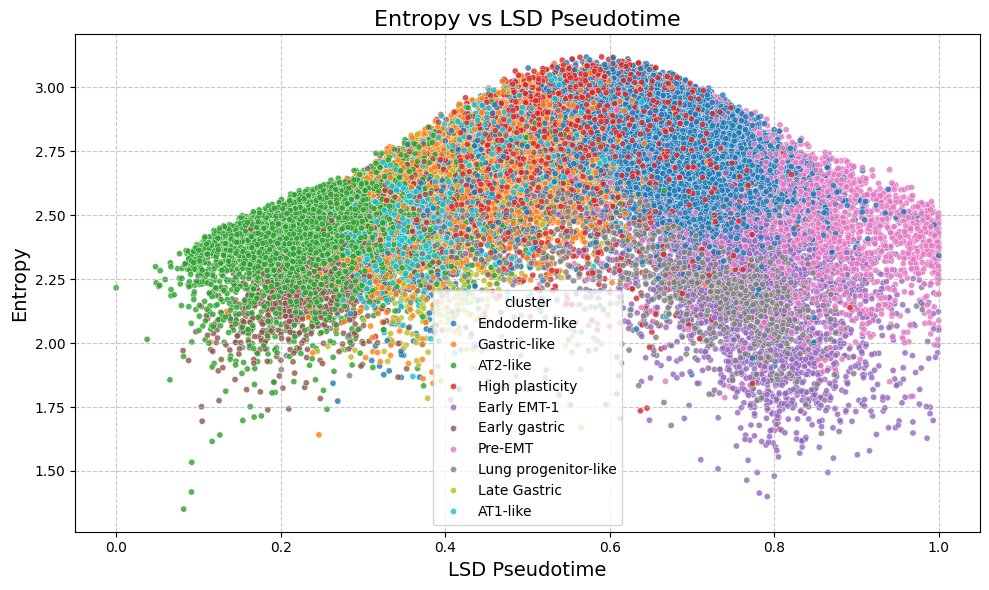

In [3]:
cfg = LSDConfig()
cfg.model.V_coeff = 1e-4
cfg.model.layer_dims.x_encoder = [512, 256, 128]
cfg.model.layer_dims.potential = [16, 16]
cfg.optimizer.adam.lr = 2e-3
cfg.optimizer.wasserstein_schedule.max_W = 1e-2
cfg.optimizer.kl_schedule.af = 2
cfg.walks.batch_size = 256
cfg.walks.path_len = 8
cfg.walks.num_walks = 8192
cfg.walks.random_state = SEED


# -----------------------------------------------------------------------------
# 6. Build & configure the LSD model
# -----------------------------------------------------------------------------
pyro.set_rng_seed(SEED)
lsd = LSD(
    adata=adata,
    config = cfg,
    device=device,
    lib_size_key="librarysize",
    raw_count_key="raw"
)

# Use the transferred phylogenetic pseudotime as prior
lsd.set_prior_transition(prior_time_key="transferred_phylo_pseudotime")

# Sample random walks through the state space
lsd.prepare_walks()


# -----------------------------------------------------------------------------
# 7. Train the model
# -----------------------------------------------------------------------------
pyro.clear_param_store()
lsd.train(
    num_epochs=100,
    save_dir="../../Models/Cancer_model",
    save_interval=50
)

# -----------------------------------------------------------------------------
# 8. Extract and visualize results
# -----------------------------------------------------------------------------
final_adata = lsd.get_adata()

# UMAP & diffusion embedding streamlines
sc.pl.umap(
    final_adata,
    color=["clusters", "entropy", "potential", "lsd_pseudotime"],
    title="Final UMAP: LSD outputs"
)
sc.pl.embedding(
    final_adata,
    basis="diff_rep",
    color=["clusters", "entropy", "potential", "lsd_pseudotime"],
    title="Diffusion Rep. embedding"
)
lsd.stream_lines(embedding="X_umap")

# -----------------------------------------------------------------------------
# 9. Helper for scatter-plots of features over time
# -----------------------------------------------------------------------------
def scatter_time_feature(df, feature, ylabel, title):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=df, x="time", y=feature, hue="cluster", s=20, alpha=0.8
    )
    plt.xlabel("LSD Pseudotime", fontsize=14)
    plt.ylabel(ylabel, fontsize=14)
    plt.title(title, fontsize=16)
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()

# Prepare DataFrame
df = pd.DataFrame({
    "time":                   final_adata.obs["lsd_pseudotime"].values,
    "potential":              final_adata.obs["potential"].values,
    "entropy":                final_adata.obs["entropy"].values,
    "cluster":                final_adata.obs["clusters"].values,
})

# Plot each feature vs time
scatter_time_feature(df, "entropy",       "Entropy",     "Entropy vs LSD Pseudotime")

In [4]:

plasticity_df = pd.read_csv("plasticity_scores.tsv", sep="\t")

# Extract obs_names, entropy, and time from temp_adata
obs_df = final_adata.obs[['entropy', 'transferred_phylo_pseudotime']].copy()  # Keep entropy and time columns
obs_df.index.name = "Unnamed: 0"  # Ensure index matches the column name in plasticity_df
obs_df.reset_index(inplace=True)  # Convert index to a column for merging

# Perform an inner join on the "Unnamed: 0" column to keep only mutual cells
merged_df = plasticity_df.merge(obs_df, on="Unnamed: 0", how="inner")

# Rename columns properly (optional)
merged_df.rename(columns={"entropy": "Entropy", "transferred_phylo_pseudotime": "Time"}, inplace=True)

# merged_df.to_csv("filtered_plasticity.tsv", sep="\t", index=False)  # Save if needed


normal_entropy = (merged_df['Entropy'].values - np.min(merged_df['Entropy'].values))/(np.max(merged_df['Entropy'].values) - np.min(merged_df['Entropy'].values))
merged_df['Entropy'] = normal_entropy


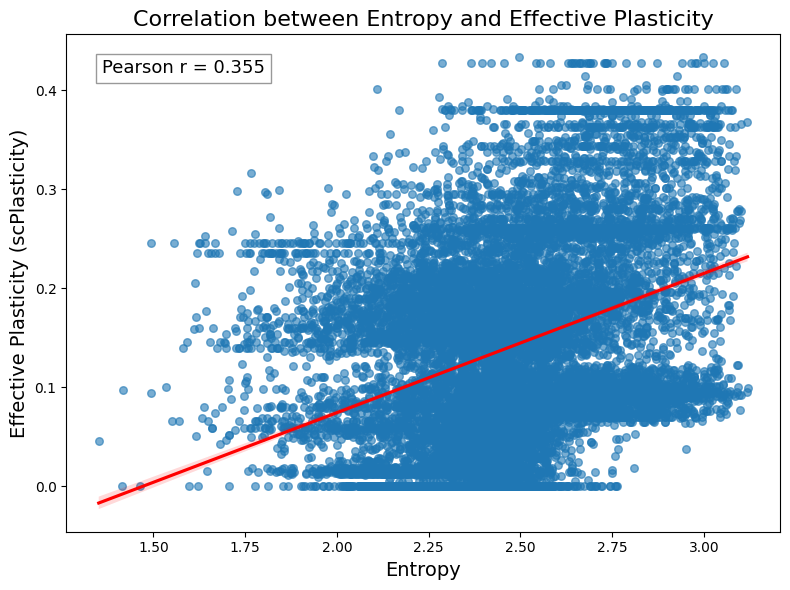

In [ ]:
merged_df = merged_df.set_index("Unnamed: 0")
final_adata.obs['scPlasticity'] = merged_df['scPlasticity']  # adjust column name as needed
# Step 1: Filter clusters with ≥50% scPlasticity values
df_full = final_adata.obs[['clusters', 'entropy', 'scPlasticity']].copy()
df_full['clusters'] = df_full['clusters'].astype(str)

# Calculate percentage of non-missing scPlasticity per cluster
valid_cluster_percent = (
    df_full.groupby('clusters')['scPlasticity']
    .apply(lambda x: x.notna().mean())
)

# Keep clusters with at least 50% valid scPlasticity values
valid_clusters = valid_cluster_percent[valid_cluster_percent >= 0.5].index
df = df_full[df_full['clusters'].isin(valid_clusters)].dropna(subset=['entropy', 'scPlasticity'])

# Step 2: Calculate correlations
pearson_r, pearson_p = pearsonr(df['scPlasticity'], df['entropy'])
spearman_r, spearman_p = spearmanr(df['scPlasticity'], df['entropy'])

# Step 3: Create scatterplot with regression line
plt.figure(figsize=(8, 6))
sns.regplot(
    y='scPlasticity',
    x='entropy',
    data=df,
    scatter_kws={'alpha': 0.6, 's': 30},
    line_kws={'color': 'red'}
)

# Annotate correlation coefficients
plt.text(
    0.05, 0.95,
    f'Pearson r = {pearson_r:.3f}',
    ha='left', va='top', transform=plt.gca().transAxes,
    fontsize=13,
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray')
)

# Aesthetic details
plt.ylabel('Effective Plasticity (scPlasticity)', fontsize=14)
plt.xlabel('Entropy', fontsize=14)
plt.title('Correlation between Entropy and Effective Plasticity', fontsize=16)
plt.tight_layout()

# Save and show plot
plt.savefig('entropy_vs_plasticity_filtered.png', dpi=600)
plt.show()

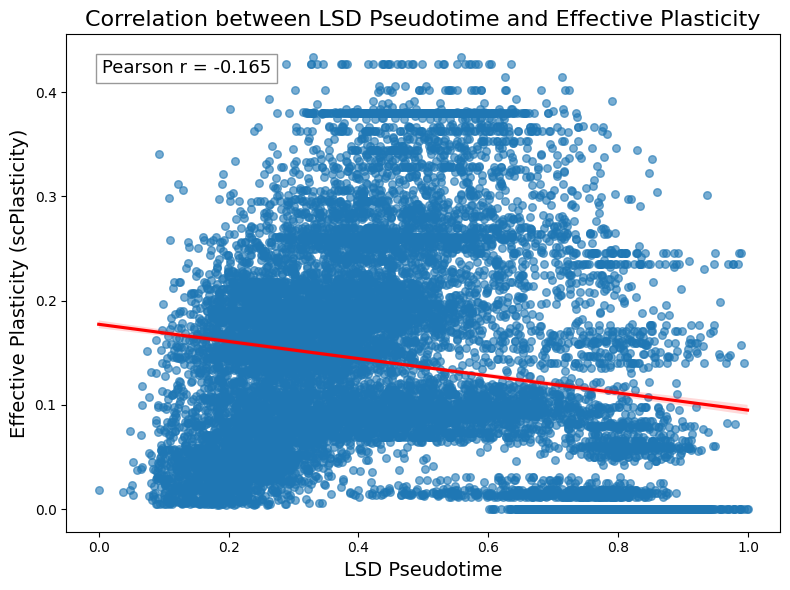

In [ ]:
# Extract relevant columns
df_full = final_adata.obs[['clusters', 'lsd_pseudotime', 'scPlasticity']].copy()
df_full['clusters'] = df_full['clusters'].astype(str)

# Filter clusters with ≥50% non-null scPlasticity values
valid_cluster_percent = (
    df_full.groupby('clusters')['scPlasticity']
    .apply(lambda x: x.notna().mean())
)
valid_clusters = valid_cluster_percent[valid_cluster_percent >= 0.5].index
df = df_full[df_full['clusters'].isin(valid_clusters)].dropna(subset=['lsd_pseudotime', 'scPlasticity'])

# Calculate correlations
pearson_r, pearson_p = pearsonr(df['scPlasticity'], df['lsd_pseudotime'])
spearman_r, spearman_p = spearmanr(df['scPlasticity'], df['lsd_pseudotime'])

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(
    y='scPlasticity',
    x='lsd_pseudotime',
    data=df,
    scatter_kws={'alpha': 0.6, 's': 30},
    line_kws={'color': 'red'}
)

# Annotate correlation
plt.text(
    0.05, 0.95,
    f'Pearson r = {pearson_r:.3f}',
    ha='left', va='top', transform=plt.gca().transAxes,
    fontsize=13,
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray')
)

# Labels and aesthetics
plt.ylabel('Effective Plasticity (scPlasticity)', fontsize=14)
plt.xlabel('LSD Pseudotime', fontsize=14)
plt.title('Correlation between LSD Pseudotime and Effective Plasticity', fontsize=16)
plt.tight_layout()

# Save the figure
plt.savefig('pseudotime_vs_plasticity_filtered.png', dpi=600)
plt.show()
